In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import math, random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Device: cpu


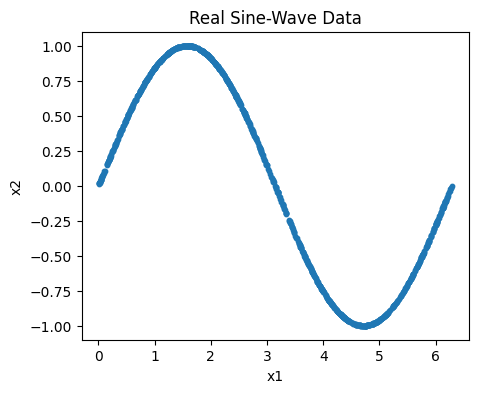

In [2]:
# Sine-wave dataset from the tutorial
n_length = 1024
sine_data = torch.zeros((n_length, 2))
sine_data[:, 0] = 2 * math.pi * torch.rand(n_length)
sine_data[:, 1] = torch.sin(sine_data[:, 0])

sine_labels = torch.zeros(n_length)

sine_set = [
    (sine_data[i], sine_labels[i])
    for i in range(n_length)
]

plt.figure(figsize=(5,4))
plt.scatter(sine_data[:, 0], sine_data[:, 1], s=10)
plt.title("Real Sine-Wave Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

batch_size=32
sine_loader = torch.utils.data.DataLoader(
    sine_set,
    batch_size=batch_size,
    shuffle=True
)


In [3]:
#discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)
discriminator = Discriminator()
#generator
class Generator(nn.Module):
    def __init__(self, z_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, z):
        return self.net(z)

generator = Generator()

In [4]:
def train_gan(generator, discriminator, loader, epochs=2000, z_dim=2, lr=0.001):
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    loss_fn = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr)
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr)

    g_losses, d_losses = [], []

    for epoch in range(epochs):
        total_g, total_d = 0, 0

        for real, _ in loader:
            real = real.to(device)
            batch_size = real.size(0)

            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Train discriminator
            z = torch.randn(batch_size, z_dim).to(device)
            fake = generator(z)

            d_input = torch.cat([real, fake.detach()])
            d_labels = torch.cat([real_labels, fake_labels])

            opt_d.zero_grad()
            d_loss = loss_fn(discriminator(d_input), d_labels)
            d_loss.backward()
            opt_d.step()

            # Train generator
            z = torch.randn(batch_size, z_dim).to(device)
            fake = generator(z)

            opt_g.zero_grad()
            g_loss = loss_fn(discriminator(fake), real_labels)
            g_loss.backward()
            opt_g.step()

            total_g += g_loss.item()
            total_d += d_loss.item()

        g_losses.append(total_g / len(loader))
        d_losses.append(total_d / len(loader))

        if epoch % 300 == 0:
            print(f"Epoch {epoch}: D Loss={d_losses[-1]:.3f}, G Loss={g_losses[-1]:.3f}")

    return g_losses, d_losses

In [5]:
Gen_sine = Generator()
Des_sine = Discriminator()

gen_loss_sine, des_loss_sine = train_gan(
    Gen_sine,
    Des_sine,
    sine_loader,
    epochs=2000,
    lr=0.001
)

Epoch 0: D Loss=0.314, G Loss=1.520
Epoch 300: D Loss=0.648, G Loss=0.838
Epoch 600: D Loss=0.680, G Loss=0.741
Epoch 900: D Loss=0.685, G Loss=0.724
Epoch 1200: D Loss=0.692, G Loss=0.741
Epoch 1500: D Loss=0.687, G Loss=0.706
Epoch 1800: D Loss=0.686, G Loss=0.720


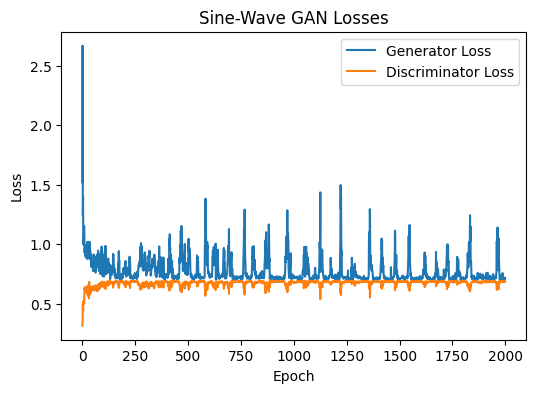

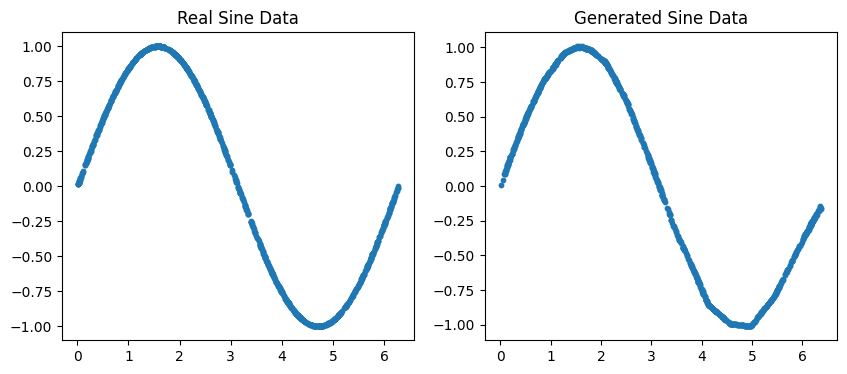

In [6]:
# Loss curves
plt.figure(figsize=(6,4))
plt.plot(gen_loss_sine, label="Generator Loss")
plt.plot(des_loss_sine, label="Discriminator Loss")
plt.title("Sine-Wave GAN Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("Figure1")
plt.show()

# Generated samples
z = torch.randn(1000, 2).to(device)
fake_sine = Gen_sine(z).detach().cpu()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(sine_data[:,0], sine_data[:,1], s=10)
plt.title("Real Sine Data")

plt.subplot(1,2,2)
plt.scatter(fake_sine[:,0], fake_sine[:,1], s=10)
plt.title("Generated Sine Data")
plt.savefig("Figure2")
plt.show()

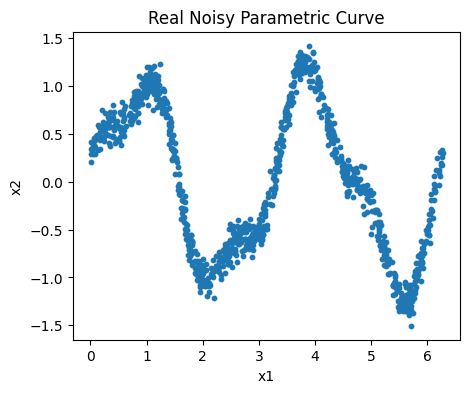

In [7]:
# Noisy dataset
# y = sin(2x) + 0.3cos(5x) + epsilon

n = 1024
x = 2 * math.pi * torch.rand(n)
epsilon = 0.1 * torch.randn(n)

y = torch.sin(2 * x) + 0.3 * torch.cos(5 * x) + epsilon

noisy_data = torch.zeros((n, 2))
noisy_data[:, 0] = x
noisy_data[:, 1] = y

plt.figure(figsize=(5,4))
plt.scatter(noisy_data[:,0], noisy_data[:,1], s=10)
plt.title("Real Noisy Parametric Curve")
plt.xlabel("x1")
plt.ylabel("x2")
plt.savefig("Figure3")
plt.show()


noisy_loader = DataLoader(
    TensorDataset(noisy_data, torch.zeros(n)),
    batch_size=32,
    shuffle=True,
    drop_last=True
)

In [8]:
G_noisy = Generator()
D_noisy = Discriminator()

g_loss_noisy, d_loss_noisy = train_gan(
    G_noisy,
    D_noisy,
    noisy_loader,
    epochs=2000,
    lr=0.001
)

Epoch 0: D Loss=0.351, G Loss=0.987
Epoch 300: D Loss=0.674, G Loss=0.785
Epoch 600: D Loss=0.670, G Loss=0.773
Epoch 900: D Loss=0.654, G Loss=0.888
Epoch 1200: D Loss=0.679, G Loss=0.735
Epoch 1500: D Loss=0.681, G Loss=0.755
Epoch 1800: D Loss=0.698, G Loss=0.767


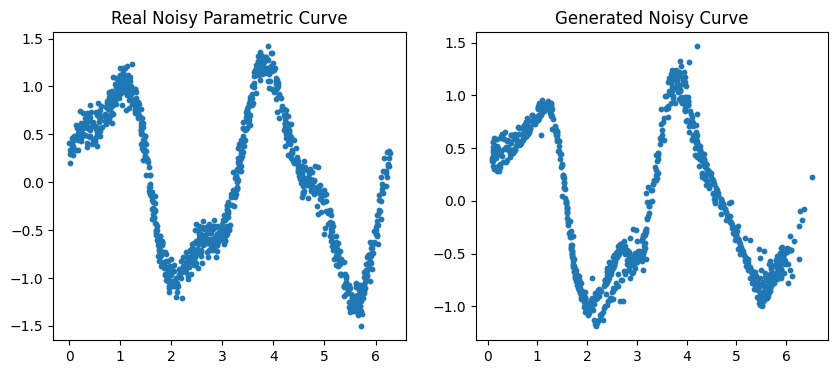

In [9]:
z = torch.randn(1000, 2).to(device)
fake_noisy_curve = G_noisy(z).detach().cpu()


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(noisy_data[:,0], noisy_data[:,1], s=10)
plt.title("Real Noisy Parametric Curve")


plt.subplot(1,2,2)
plt.scatter(fake_noisy_curve[:,0], fake_noisy_curve[:,1], s=10)
plt.title("Generated Noisy Curve")
plt.savefig("Figure4")
plt.show()

In [10]:
class ModifiedGenerator(nn.Module):
    def __init__(self, z_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 2)
        )

    def forward(self, z):
        return self.net(z)


class ModifiedDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [11]:
G_noisy_mod = ModifiedGenerator()
D_noisy_mod = ModifiedDiscriminator()

g_loss_noisy_mod, d_loss_noisy_mod = train_gan(
    G_noisy_mod,
    D_noisy_mod,
    noisy_loader,
    epochs=2500,
    lr=0.001
)

Epoch 0: D Loss=0.593, G Loss=0.661
Epoch 300: D Loss=0.695, G Loss=0.706
Epoch 600: D Loss=0.691, G Loss=0.716
Epoch 900: D Loss=0.690, G Loss=0.702
Epoch 1200: D Loss=0.687, G Loss=0.728
Epoch 1500: D Loss=0.685, G Loss=0.709
Epoch 1800: D Loss=0.688, G Loss=0.715
Epoch 2100: D Loss=0.690, G Loss=0.714
Epoch 2400: D Loss=0.691, G Loss=0.703


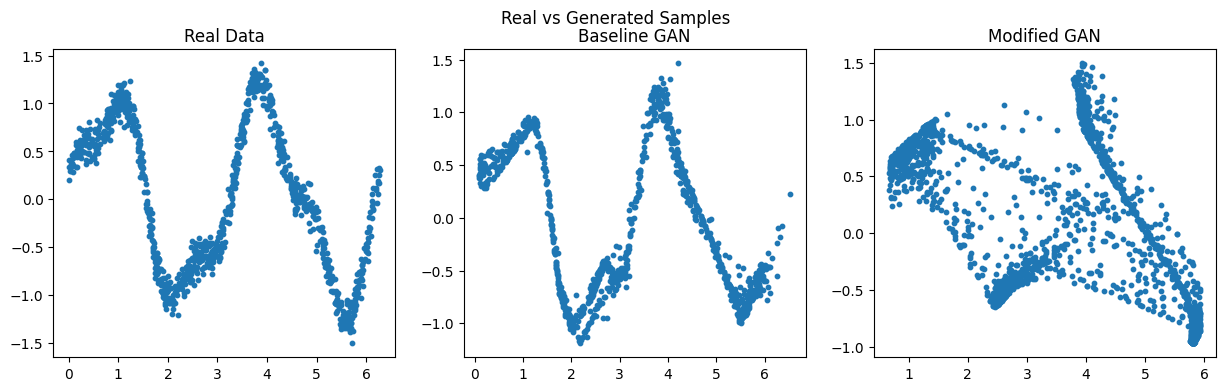

In [12]:
z = torch.randn(2000, 2).to(device)
fake_noisy_mod = G_noisy_mod(z).detach().cpu()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(noisy_data[:,0], noisy_data[:,1], s=10)
plt.title("Real Data")

plt.subplot(1,3,2)
plt.scatter(fake_noisy_curve[:,0], fake_noisy_curve[:,1], s=10)
plt.title("Baseline GAN")

plt.subplot(1,3,3)
plt.scatter(fake_noisy_mod[:,0], fake_noisy_mod[:,1], s=10)
plt.title("Modified GAN")

plt.suptitle("Real vs Generated Samples")
plt.savefig("Figure5")
plt.show()

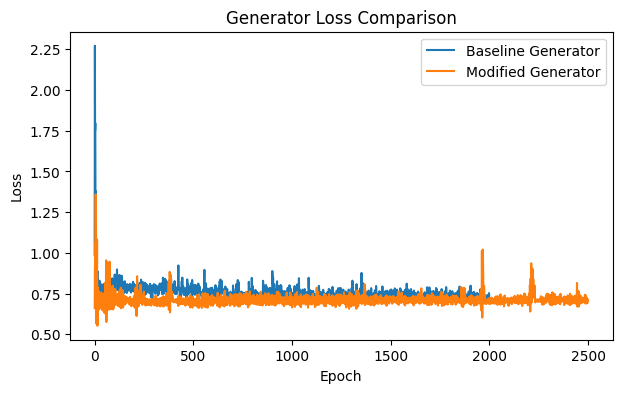

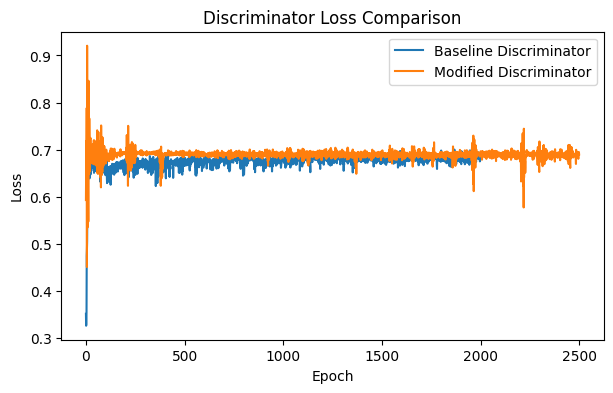

In [13]:
plt.figure(figsize=(7,4))
plt.plot(g_loss_noisy, label="Baseline Generator")
plt.plot(g_loss_noisy_mod, label="Modified Generator")
plt.title("Generator Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("Figure6")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(d_loss_noisy, label="Baseline Discriminator")
plt.plot(d_loss_noisy_mod, label="Modified Discriminator")
plt.title("Discriminator Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("Figure7")
plt.show()